# Process and View Results From Multiple Longstrips

In [1]:
#%% imports
from pathlib import Path
# import json
# import configparser
import pprint
pp = pprint.PrettyPrinter(indent=4);
import time
import math
from collections import namedtuple

# # pip install slicerio
# import slicerio.server

# # packages for 3d
# #   # for OCT 3D stuff and using in jupyter
# #   - trame-jupyter-extension
# #   - trame
# #   - trame-vtk
# #   - trame-vuetify
# #   - ipywidgets

import matplotlib.pyplot as plt
import plotly.express as px

# interactive panels
import panel as pn
pn.extension('plotly');

import numpy as np
import pandas as pd
import addict

import cv2
import skimage
import scipy.signal
import networkx as nx

import pyvista as pv
from PIL import Image
import SimpleITK as sitk

# with vedo
#from vedo import dataurl, Volume, Text2D
import vedo
vedo.settings.default_backend = 'vtk'
#from vedo.applications import Slicer3DPlotter
import naatos_oct_tools.plotters.vedo_plotters as vedo_plotters
import naatos_oct_tools.plotters.sitk_plotters as sitk_plotters

import naatos_oct_tools.thorlabs_oct_file_reading
import naatos_oct_tools.oct_linear_scan_processing

In [2]:
# Magics to autoreload submodules when they are modified
%load_ext autoreload
%autoreload 2

In [3]:
#%% Test Record Excel
dftests = pd.read_excel(
    r'C:\Users\SimonGhionea\Global Health Labs, Inc\NAATOS Product Feasibility - TB V1 - General - Internal - Wax Valve\OCT\Test\OCT_wax_valve_test_record.xlsx',
    skiprows=1
)
dftests = dftests.iloc[:,1:]
dftests.rename(columns={'Unnamed: 19':'Notes'},inplace=True)
dftests

,Test ID,Test date,Test name,Batch,Strip,Wax (mg/mm),Fixture,"X, FOV","Y, FOV","Z, FOV",...,"Z, pixel size",Angle,Right edge (mm),Left edge (mm),Strip length (mm),Speed/Sensitivity,Averaging (A-scan),File size (MB),Total size (GB),Unnamed: 22
0,NaN,2025-03-26,GHL_pyapp_20250326T1258,oven aging test day 1,strip 7,NaN,"old, with tape",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,2025-03-26,GHL_pyapp_20250326T1403,oven aging test day 1,strip 10,NaN,"old, with tape",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,2025-03-26,GHL_pyapp_20250326T1416,oven aging test day 1,strip 14,NaN,"old, with tape",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,2025-03-27,GHL_pyapp_20250327T1428,oven aging test day 2,strip 7,NaN,"old, with 3d print clamps",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,2025-03-27,GHL_pyapp_20250327T1438,oven aging test day 2,strip 10,NaN,"old, with 3d print clamps",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,2025-03-27,GHL_pyapp_20250327T1450,oven aging test day 2,strip 14,NaN,"old, with 3d print clamps",NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1.0,2025-04-14,GHL_pyapp_20250414T1541,0.3-0.324 mg/mm,0.302 02-13 10,0.302,1-sided magnetic,7.0,9.0,1.5,...,2.17,NaN,105.1,-60.0,165.1,"Medium, 48kHz",2.0,425.0,8.1,Accidentually deleted
7,2.0,2025-04-14,GHL_pyapp_20250414T1610,0.3-0.324 mg/mm,0.308 02-26 11,0.308,1-sided magnetic,7.0,9.0,1.5,...,2.17,NaN,105.1,-60.0,165.1,"Medium, 48kHz",2.0,425.0,8.1,NaN
8,3.0,2025-04-14,GHL_pyapp_20250414T1618,0.3-0.324 mg/mm,0.302 02-13 10,0.302,1-sided magnetic,7.0,9.0,1.5,...,2.17,NaN,105.1,-60.0,165.1,"Medium, 48kHz",2.0,425.0,8.1,Repeat test 1
9,4.0,2025-04-14,GHL_pyapp_20250414T1636,0.3-0.324 mg/mm,ES0331 #26 0.320,0.320,1-sided magnetic,7.0,9.0,1.5,...,2.17,NaN,104.8,-60.5,165.3,"Medium, 48kHz",2.0,425.0,8.1,NaN


In [4]:
#%% Filter The Tests To View
# dfmasks = [
#     (dftests['Test date']<'2025-03-28') & (dftests['Test date']>='2025-03-26'),
#     dftests['Test name'] != 'GHL_pyapp_20250326T1258'
# ]
# dfmasks = [
#     (dftests['Test date']<='2025-04-15') & (dftests['Test date']>='2025-04-14')
# ]
dfmasks = [
    (dftests['Test date']=='2025-05-05')
]

dffilt = dftests[np.all(dfmasks,axis=0)]
dffilt

,Test ID,Test date,Test name,Batch,Strip,Wax (mg/mm),Fixture,"X, FOV","Y, FOV","Z, FOV",...,"Z, pixel size",Angle,Right edge (mm),Left edge (mm),Strip length (mm),Speed/Sensitivity,Averaging (A-scan),File size (MB),Total size (GB),Unnamed: 22
18,13.0,2025-05-05,GHL_pyapp_20250505T1514,0.325-0.35,ES0408#12 0.329,0.329,Vacuum,9.0,3.5,1.5,...,2.17,0.0,307.5,142.5,165.0,"Medium, 48kHz",2.0,213.0,4.1,NaN
19,14.0,2025-05-05,GHL_pyapp_20250505T1523,0.325-0.35,ES0408#11 0.336,0.336,Vacuum,9.0,3.5,1.5,...,2.17,0.0,307.5,142.5,165.0,"Medium, 48kHz",2.0,213.0,4.1,NaN
20,15.0,2025-05-05,GHL_pyapp_20250505T1531,0.375-0.4,ES0331#10 0.387,0.387,Vacuum,9.0,3.5,1.5,...,2.17,0.0,307.5,142.5,165.0,"Medium, 48kHz",2.0,213.0,4.1,NaN
21,16.0,2025-05-05,GHL_pyapp_20250505T1542,0.375-0.4,ES0331#4 0.384,0.384,Vacuum,9.0,3.5,1.5,...,2.17,0.0,307.5,142.5,165.0,"Medium, 48kHz",2.0,213.0,4.1,NaN


In [5]:
#%% Load OCT study information
octstudies = [];
#folder_octexport_root = Path(r'\\file.corp.ghlabs.org\Shared\Projects\NAATOS\V1\NAATOS_OCT_WORK\OCTExport')
folder_octexport_root = Path(r'D:\SGProjects\NAATOS\OCTlocal')

# Load list of data
for idx,record in dffilt.iterrows():
    octstudy = naatos_oct_tools.thorlabs_oct_file_reading.OCT_Study_Folder(record['Test name'],folder_octexport_root);
    octstudies.append(octstudy);


STUDY: GHL_pyapp_20250505T1514
{   'study_has_an_ini_file': True,
    'study_has_json_info_file': True,
    'study_has_yat_log': False,
    'study_num_jpg_files': 0,
    'study_num_oct_files': 20,
    'study_num_vtk_files': 0}
STUDY: GHL_pyapp_20250505T1523
{   'study_has_an_ini_file': True,
    'study_has_json_info_file': True,
    'study_has_yat_log': False,
    'study_num_jpg_files': 0,
    'study_num_oct_files': 20,
    'study_num_vtk_files': 0}
STUDY: GHL_pyapp_20250505T1531
{   'study_has_an_ini_file': True,
    'study_has_json_info_file': True,
    'study_has_yat_log': False,
    'study_num_jpg_files': 0,
    'study_num_oct_files': 20,
    'study_num_vtk_files': 0}
STUDY: GHL_pyapp_20250505T1542
{   'study_has_an_ini_file': True,
    'study_has_json_info_file': True,
    'study_has_yat_log': False,
    'study_num_jpg_files': 0,
    'study_num_oct_files': 20,
    'study_num_vtk_files': 0}


In [6]:
# Master Parameters
oct_scalar_min = 30;
oct_scalar_max = 60;

# Parse Through The OCTSTUDIES

In [82]:
#%% Load OCTSTUDY object, and start some processing on it
octstudies_to_run = [];
for idx,octstudy in enumerate(octstudies):
    octstudy : naatos_oct_tools.thorlabs_oct_file_reading.OCT_Study_Folder;
    print('~~~~~~~');
    print(octstudy.name);
    pp.pprint(octstudy.resultsCheck())
    doWeRunTheNotebook = any([v is False for k,v in octstudy.resultsCheck().items()])
    print('Run?',doWeRunTheNotebook)
    if(not doWeRunTheNotebook):
        octstudies_to_run.append(octstudy);

    print('~~~~~~~');
    print('We will analyze data for {:} octstudies.'.format(len(octstudies_to_run)))
    print([x.name for x in octstudies_to_run])

~~~~~~~
GHL_pyapp_20250505T1514
{   'along_strip_data_extracted': [   '/dfstepA',
                                      '/dfstepB',
                                      '/dfstepC',
                                      '/dfstepD',
                                      '/dfstepE'],
    'exist_data_extracted': True,
    'figoutmp4_stepA': True,
    'figoutmp4_stepB': True}
Run? False
~~~~~~~
We will analyze data for 1 octstudies.
['GHL_pyapp_20250505T1514']
~~~~~~~
GHL_pyapp_20250505T1523
{   'along_strip_data_extracted': [   '/dfstepA',
                                      '/dfstepB',
                                      '/dfstepC',
                                      '/dfstepD'],
    'exist_data_extracted': True,
    'figoutmp4_stepA': True,
    'figoutmp4_stepB': True}
Run? False
~~~~~~~
We will analyze data for 2 octstudies.
['GHL_pyapp_20250505T1514', 'GHL_pyapp_20250505T1523']
~~~~~~~
GHL_pyapp_20250505T1531
{   'along_strip_data_extracted': [   '/dfstepA',
                   

# 1. From stored dataframes load summary data we care about

In [83]:
octstudies_to_run = [octstudies_to_run[3]]
for idx,octstudy in enumerate(octstudies_to_run):
    print(octstudy.name)

    octstudy.load_previously_saved_merged_volume();

    data_extracted = octstudy.load_data_extracted();
    dfsteps = octstudy.load_data_extracted_along_strip();
    #data_extracted = 


    # Calculate Path From Top To Bottom
    

    break;

GHL_pyapp_20250505T1542
Loading GHL_pyapp_20250505T1542_STACKED_RESCALED_30to60_uint8.vtk
Loading /dfstepA
Loading /dfstepB
Loading /dfstepC
Loading /dfstepD


In [84]:
dfsteps

,pixel_depth_strip_top_sum_threshold,pixel_depth_strip_top,pixel_depth_strip_bot,pixel_depth_wax_center,px_wax_transverse_edges,wax_top_seed_candidate_px,pksA,pksB,pksB2,wax_roi_valve_bottom,testseg_otsu_regions,testseg_otsu_thresholds,final_wax_bot_subset_px,seg_thresh_sauvola_cutoff,area,area_filled,area_convex
slice,,,,,,,,,,,,,,,,,
5,59.00,203,263,240,"(65.98214285714286, 114.86496350364963)","(214, 89)","([10, 44, 95, 131, 185], {'prominences': [6811...","([10, 90, 133, 187, 224], {'prominences': [359...","([11, 187, 237], {'peak_heights': [3884.497942...",237,"[[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,...","[67, 103, 141, 199]",188,"[[False, False, False, False, False, False, Fa...",5679.0,6073.0,8250.0
10,62.20,203,262,256,"(65.81428571428572, 115.73134328358209)","(214, 90)","([13, 66, 116], {'prominences': [6097.0, 742.0...","([12, 64, 188], {'prominences': [4344.0, 354.0...","([12, 188, 219], {'peak_heights': [4419.027539...",188,"[[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,...","[66, 102, 144, 202]",186,"[[False, False, False, False, False, False, Fa...",5898.0,6279.0,7895.0
15,60.96,203,262,256,"(64.09016393442623, 118.65602836879432)","(216, 91)","([15, 69, 117], {'prominences': [5969.0, 973.0...","([13, 70, 185, 215], {'prominences': [5142.0, ...","([14, 70, 186, 218, 380], {'peak_heights': [45...",186,"[[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,...","[63, 100, 144, 200]",184,"[[False, False, False, False, False, False, Fa...",6225.0,6642.0,8444.0
20,58.80,204,262,255,"(62.2037037037037, 118.64948453608247)","(216, 90)","([9, 46, 81, 112], {'prominences': [4975.0, 15...","([12, 67, 141, 184], {'prominences': [5128.0, ...","([14, 184, 224], {'peak_heights': [4400.160715...",184,"[[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,...","[59, 95, 140, 198]",183,"[[False, False, False, False, False, False, Fa...",6722.0,6976.0,9394.0
25,58.44,206,263,255,"(61.19892473118279, 117.15425531914893)","(216, 89)","([9, 58, 92, 183], {'prominences': [4005.0, 38...","([9, 91, 183, 234, 403], {'prominences': [3953...","([9, 183, 239, 403], {'peak_heights': [4328.43...",239,"[[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,...","[55, 88, 131, 193]",180,"[[False, False, False, False, False, False, Fa...",6715.0,6715.0,8955.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7785,55.48,367,423,407,"(58.97328244274809, 128.29365079365078)","(388, 92)","([10, 77, 154], {'prominences': [6419.0, 2117....","([14, 77, 167, 202], {'prominences': [7435.0, ...","([14, 167, 202], {'peak_heights': [4212.780622...",167,"[[1, 1, 2, 2, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4,...","[62, 101, 147, 200]",167,"[[False, False, False, False, False, False, Fa...",7109.0,7155.0,9478.0
7790,56.56,367,421,395,"(59.878787878787875, 126.84693877551021)","(385, 92)","([10, 46, 82, 154], {'prominences': [6987.0, 3...","([12, 80, 161, 202, 243], {'prominences': [721...","([12, 164, 202], {'peak_heights': [4455.918676...",164,"[[2, 2, 2, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,...","[62, 101, 147, 201]",164,"[[False, False, False, False, False, False, Fa...",6981.0,7054.0,9013.0
7795,57.88,367,420,405,"(61.78333333333333, 125.51680672268908)","(384, 93)","([14, 59, 92, 153], {'prominences': [6045.0, 4...","([13, 158, 200], {'prominences': [7041.0, 4681...","([13, 158, 200], {'peak_heights': [4288.450921...",158,"[[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,...","[64, 106, 153, 206]",158,"[[False, False, False, False, False, False, Fa...",6380.0,6559.0,8380.0


# handle the source image

In [85]:
# Test getting SITK image
# Get ITK image without requiring new memory
import itk
import vtk

# function to go from itk image to simpleitk image
def itkToSimpleITK(itk_image):
    new_sitk_image = sitk.GetImageFromArray(itk.GetArrayViewFromImage(itk_image),isVector=itk_image.GetNumberOfComponentsPerPixel()>1);
    new_sitk_image.SetOrigin(tuple(itk_image.GetOrigin()))
    new_sitk_image.SetSpacing(tuple(itk_image.GetSpacing()))
    new_sitk_image.SetDirection(itk.GetArrayFromMatrix(itk_image.GetDirection()).flatten()) 
    return new_sitk_image;

# create simpleitk 3dimage, directly from the previously-loaded vtk 3dimage
simgmerged = itkToSimpleITK( itk.image_from_vtk_image(octstudy.vdvol.dataset) );



# itk_image
#print(itk_image)
slicer_1 = slice( data_extracted['auto_bounds']['topdown_edge_left_px3']  ,  data_extracted['auto_bounds']['topdown_edge_right_px3']  )
#print(' slicer_dim_0',slicer_0)
print(' slicer_dim_1',slicer_1)
#simgmerged.GetSize()

 slicer_dim_1 slice(249, 8059, None)


# 2. Calculate paths through segmentation

Shape (63, 193)
Min Top Col inf
Max Top Col inf
idxmin_end_col path 0
idxmax_end_col path 0
slice(61.815, 124.90495867768595, None)
slice(369, 562, None)


({'num_paths': 0}, <Figure size 1400x1000 with 7 Axes>)

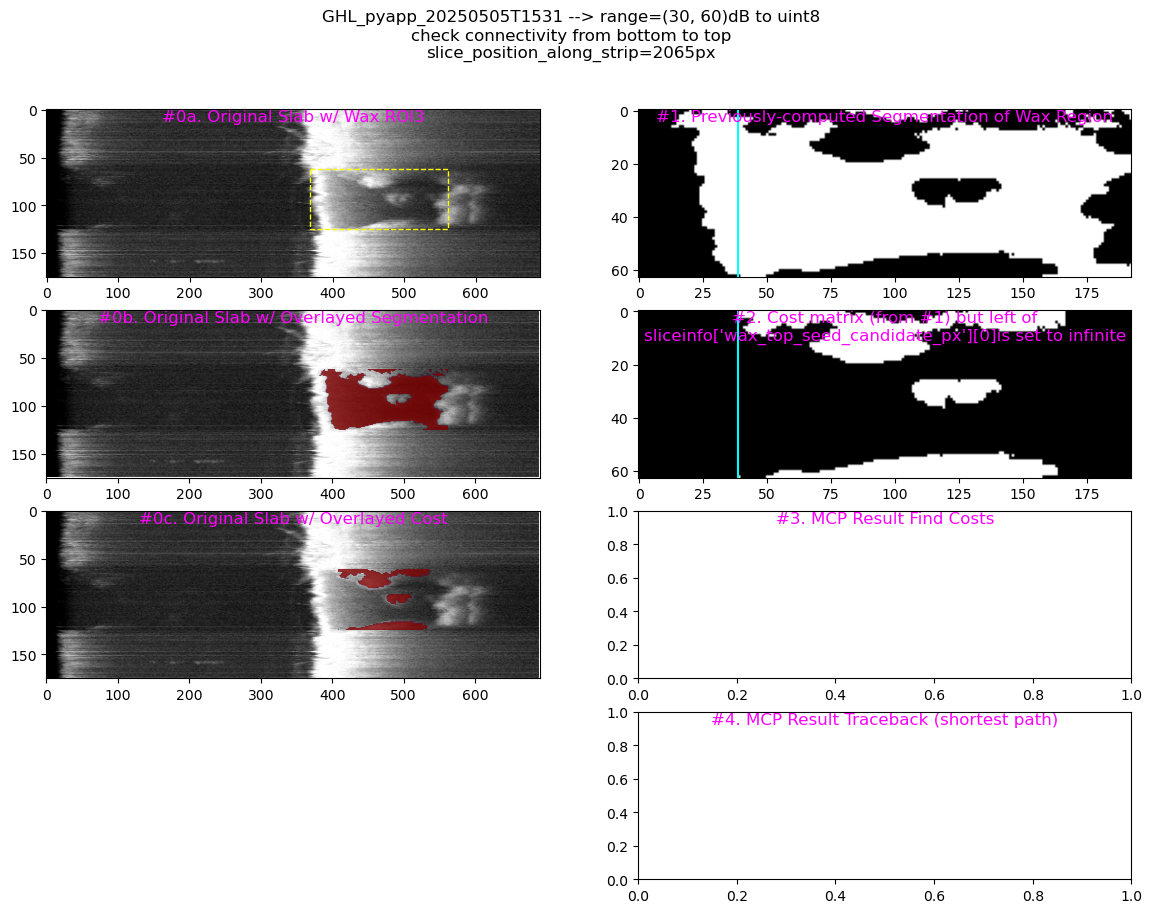

In [78]:
import matplotlib.patches
def mkfig(slice_position_along_strip_px):
    data={};
    #sliceinfo = dfsteps.iloc[412];
    sliceinfo = dfsteps.loc[slice_position_along_strip_px];
    sliceseg = sliceinfo['seg_thresh_sauvola_cutoff'];
    print('Shape',sliceseg.shape)


    fig = plt.figure(figsize=(14,10));
    gs = fig.add_gridspec(4,2);
    fig.suptitle('{:s} --> range={:s}dB to uint8\ncheck connectivity from bottom to top\nslice_position_along_strip={:.0f}px'.format(octstudy.name,str((oct_scalar_min,oct_scalar_max)),sliceinfo.name))


    # will cut off / not consider connections too close to the strip surface
    #cutoff_depth = (sliceinfo['pixel_depth_strip_bot']-sliceinfo['pixel_depth_strip_top']);
    cutoff_depth = (sliceinfo['wax_top_seed_candidate_px'][0]-sliceinfo['pixel_depth_strip_top']) + (sliceinfo['pixel_depth_strip_bot']-sliceinfo['pixel_depth_strip_top'])//2
    # don't consider connectons near the "bottom" of the segmentation
    cutoff_wax_bottom = sliceseg.shape[1]-int((sliceseg.shape[1]-cutoff_depth)*0.175);

    ax = fig.add_subplot(gs[0,1]);
    ax.imshow(sliceseg,aspect='auto',cmap='gray')
    ax.axvline(cutoff_depth-0.5,color='cyan')
    ax.set_title('#1. Previously-computed Segmentation of Wax Region',color='magenta',y=0.95,verticalalignment='top')

    bot_side = sliceseg.shape[0];
    top_side = 0;
    ntracebacks = 0;

    img = ~sliceseg;
    img[:,0:cutoff_depth] = False
    img[:,cutoff_wax_bottom:] = False

    costarray = (img.astype(int))-1;
    costarray[costarray==0] = 1;
    costarray[:,0:cutoff_depth] = -1
    costarray[:,cutoff_wax_bottom:] = -1;

    ax = fig.add_subplot(gs[1,1]);
    ax.imshow(costarray,aspect='auto',cmap='gray')
    #ax.axvline((sliceinfo['pixel_depth_strip_bot']-sliceinfo['pixel_depth_strip_top'])-0.5)
    ax.axvline(cutoff_depth-0.5,color='cyan')
    ax.set_title("#2. Cost matrix (from #1) but left of\nsliceinfo['wax_top_seed_candidate_px'][0]is set to infinite",color='magenta',y=0.95,verticalalignment='top')



    # graph, find path from shortest to longest
    top_source_points_col = np.where(costarray[top_side,:]==1)[0]
    top_source_points_row = np.ones_like(top_source_points_col)*top_side;
    top_source_points = np.stack([top_source_points_row,top_source_points_col],axis=1)
    #top_source_points = (top_source_points_row,top_source_points_col);


    bot_source_points_col = np.where(costarray[bot_side-1,:]==1)[0]
    bot_source_points_row = np.ones_like(bot_source_points_col)*(bot_side-1);
    bot_source_points = np.stack([bot_source_points_row,bot_source_points_col],axis=1)

    goodtraceback = False;

    if(top_source_points.shape[0]!=0 and bot_source_points.shape[0]!=0):
            


        #ret = skimage.graph.route_through_array(~sliceseg,start=(bot_source_points_row[0],bot_source_points_col[0]),end=(top_source_points_row[0],top_source_points_col[0]))
        #ret = skimage.graph.route_through_array(~sliceseg,start=(bot_source_points_row[0],bot_source_points_col[0]),end=(top_source_points_row[0],top_source_points_col[0]))


        # Sk Image Graph MCP Module
        #m = skimage.graph.MCP( costarray , fully_connected=True );
        m = skimage.graph.MCP_Geometric( costarray ,fully_connected=True);
        #ret = m.find_costs(starts=[bot_source_points.tolist()[0]],ends=[top_source_points.tolist()[0]],find_all_ends=True);
        #ret = m.find_costs(starts=bot_source_points.tolist(),ends=[[tuple(x) for x in top_source_points.tolist()][0]],find_all_ends=False);
        ret = m.find_costs(starts=bot_source_points.tolist(),ends=top_source_points.tolist(),find_all_ends=True);
        #ret = m.find_costs(starts=top_source_points.tolist(),ends=bot_source_points.tolist(),find_all_ends=True);

        print('Min Top Col',np.min(ret[0][top_side,:]));
        print('Max Top Col',np.max(ret[0][top_side,:]));
        idxmin_end_col = np.argmin(ret[0][top_side,:]);
        idxmax_end_col = np.argmax(ret[0][top_side,:]);

        print('idxmin_end_col path',idxmin_end_col);
        print('idxmax_end_col path',idxmax_end_col);

        if(np.min(ret[0][top_side,:]) != np.inf):
            if False:
                traceback = m.traceback((top_side,idxmin_end_col))
                print(traceback)
                ax.plot( np.array(traceback)[:,1]-0 , np.array(traceback)[:,0]-0 , color='red' )
            if False:
                ntracebacks = np.where(~np.isinf( ret[0][bot_side-1,:] ))[0].shape[0];
                traceback = m.traceback((top_side,idxmin_end_col))
                print(traceback)
                ax.plot( np.array(traceback)[:,1]-0 , np.array(traceback)[:,0]-0 , color='red' )
                ax.text(
                    x=0.05,  # x-coordinate (0 is left, 1 is right)
                    y=0.5,  # y-coordinate (0 is bottom, 1 is top)
                    s="Num Paths\nacross {:d}".format(ntracebacks),  # Text string
                    fontsize=15,
                    ha="left",  # Horizontal alignment
                    va="top",  # Vertical alignment
                    color='yellow',
                    transform=ax.transAxes # Specify that coordinates are axis-normalized
                )
            if False:
                ntracebacks = 0
                #for col in np.where(~np.isinf( ret[0][bot_side-1,:] ))[0]:
                for col in top_source_points_col:
                    try:
                        traceback = m.traceback((top_side,col))
                        ntracebacks+=1;
                        print(traceback)
                    except ValueError:
                        traceback = None
                    if(traceback is not None):
                        ax.plot( np.array(traceback)[:,1]-0 , np.array(traceback)[:,0]-0 , color='red' )
                ax.text(
                    x=0.05,  # x-coordinate (0 is left, 1 is right)
                    y=0.5,  # y-coordinate (0 is bottom, 1 is top)
                    s="Num Paths\nacross {:d}".format(ntracebacks),  # Text string
                    fontsize=15,
                    ha="left",  # Horizontal alignment
                    va="top",  # Vertical alignment
                    color='yellow',
                    transform=ax.transAxes # Specify that coordinates are axis-normalized
                )

                # for col in np.where(~np.isinf( ret[0][bot_side-1,:] ))[0]:
                #     try:
                #         traceback = m.traceback((top_side))
                #         tracebacks+=1;
                #     except ValueError:
                #         pass;
            if True:
                # setup networkx graph from pixels
                retg = skimage.graph.pixel_graph(img,sparse_type='array',connectivity=4)
                G = nx.from_scipy_sparse_array(retg[0])

                # compare raveled indices of top and bottom points, get graph node numbers
                raveled_graph_idx_node = retg[1][np.array(range(retg[0].shape[0]))];
                top_source_ravelidx = np.ravel_multi_index( (top_source_points[:,0],top_source_points[:,1]) , sliceseg.shape)
                print(top_source_ravelidx)
                bot_source_ravelidx = np.ravel_multi_index( (bot_source_points[:,0],bot_source_points[:,1]) , sliceseg.shape)
                print(bot_source_ravelidx)
                nodes_top = np.where(np.isin(raveled_graph_idx_node,top_source_ravelidx))[0]
                nodes_bot = np.where(np.isin(raveled_graph_idx_node,bot_source_ravelidx))[0]

                ntracebacks = 0
                # for col in top_source_points_col:
                #     try:
                #         traceback = m.traceback((top_side,col))
                #         ntracebacks+=1;
                #         print(traceback)
                #     except ValueError:
                #         traceback = None
                #     if(traceback is not None):
                #         ax.plot( np.array(traceback)[:,1]-0 , np.array(traceback)[:,0]-0 , color='red' )
                # for node in nodes_bot:
                #     try:
                #         r = nx.multi_source_dijkstra(G,sources=nodes_top.tolist(),target=node)
                #         print('Good path to',node);
                #         patharr = np.array(np.unravel_index(raveled_graph_idx_node[r[1]],shape=img.shape));
                #         ax.plot( patharr[1,:], patharr[0,:] , color='red' )
                #         ntracebacks+=1;
                #     except nx.NetworkXNoPath as e:
                #         print('No path to',node);
                # for node in nodes_top:
                #     try:
                #         r = nx.multi_source_dijkstra(G,sources=nodes_bot.tolist(),target=node)
                #         print('Good path to',node);
                #         patharr = np.array(np.unravel_index(raveled_graph_idx_node[r[1]],shape=img.shape));
                #         ax.plot( patharr[1,:], patharr[0,:] , color='red' )
                #         ntracebacks+=1;
                #     except nx.NetworkXNoPath as e:
                #         print('No path to',node);
                top_applicable_cols = np.where(~np.isinf( ret[0][top_side,:] ))[0];
                top_applicable_rows = np.ones_like(top_applicable_cols)*(top_side);
                top_nodes_applicable = np.where(np.isin(raveled_graph_idx_node,np.ravel_multi_index((top_applicable_rows,top_applicable_cols), sliceseg.shape)))[0];
                for nodetop in top_nodes_applicable:
                    for nodebot in nodes_bot:
                        try:
                            r = nx.multi_source_dijkstra(G,sources=[nodebot],target=nodetop)
                            print('Good path {:} to {:}'.format(nodebot,nodetop));
                            patharr = np.array(np.unravel_index(raveled_graph_idx_node[r[1]],shape=img.shape));
                            ax.plot( patharr[1,:]+0, patharr[0,:]+0 , color='red' )
                            ntracebacks+=1;
                        except nx.NetworkXNoPath as e:
                            print('No path {:} to {:}'.format(nodebot,nodetop));
                ax.text(
                    x=0.05,  # x-coordinate (0 is left, 1 is right)
                    y=0.5,  # y-coordinate (0 is bottom, 1 is top)
                    s="Num Paths\nacross {:d}".format(ntracebacks),  # Text string
                    fontsize=15,
                    ha="left",  # Horizontal alignment
                    va="top",  # Vertical alignment
                    color='yellow',
                    transform=ax.transAxes # Specify that coordinates are axis-normalized
                )


            ax = fig.add_subplot(gs[2,1]);
            ax.set_title("#3. MCP Result Find Costs",color='magenta',y=0.95,verticalalignment='top')
            ax.imshow(ret[0],aspect='auto',cmap='jet')


            ax = fig.add_subplot(gs[3,1]);
            ax.imshow(ret[1],aspect='auto',cmap='jet')
            ax.set_title("#4. MCP Result Traceback (shortest path)",color='magenta',y=0.95,verticalalignment='top')
            goodtraceback = True;

    if(not goodtraceback):
        ax = fig.add_subplot(gs[2,1]);
        ax.set_title("#3. MCP Result Find Costs",color='magenta',y=0.95,verticalalignment='top')
        ax = fig.add_subplot(gs[3,1]);
        ax.set_title("#4. MCP Result Traceback (shortest path)",color='magenta',y=0.95,verticalalignment='top')

    # plot the original unmodified image (for comparison)
    if True:
        #octstudy.pv
        #sitk.Project
        roi3_slice_y = slice(sliceinfo['pixel_depth_strip_top'].item(),sliceinfo['pixel_depth_strip_top'].item()+sliceinfo['final_wax_bot_subset_px'].item());
        #roi3_slice_y = slice(sliceinfo['wax_top_seed_candidate_px'][0],sliceinfo['wax_top_seed_candidate_px'][0]+sliceinfo['final_wax_bot_subset_px'].item());
        roi3_slice_x = slice(sliceinfo['px_wax_transverse_edges'][0],sliceinfo['px_wax_transverse_edges'][1]);
        print(roi3_slice_x)
        print(roi3_slice_y)

        #rect2 = matplotlib.patches.Rectangle( (slicey.start, slicex.start), (slicey.start+dfstepB.loc[slice_position_along_strip_px]['final_wax_bot_subset_px'] )-slicey.start, slicex.stop-slicex.start, linewidth=1, edgecolor='yellow', linestyle='dotted',facecolor='none')

        slab_thickness = 10; # px, this was used in the bulk analysis
        slab_slicer = slice(slice_position_along_strip_px-slab_thickness//2,slice_position_along_strip_px+slab_thickness//2);
        simg_slab_img = sitk.MeanProjection((simgmerged[:,slicer_1,:])[:,slab_slicer,:],projectionDimension=1);
        ndaslab = np.squeeze(sitk.GetArrayViewFromImage(simg_slab_img));

        ax = fig.add_subplot(gs[0,0]);
        ax.imshow(ndaslab,cmap='gray',aspect='auto')
        ax.set_title('#0a. Original Slab w/ Wax ROI3',color='magenta',y=0.95,verticalalignment='top')
        rect = matplotlib.patches.Rectangle( (roi3_slice_y.start, roi3_slice_x.start), roi3_slice_y.stop-roi3_slice_y.start, roi3_slice_x.stop-roi3_slice_x.start, linewidth=1, edgecolor='yellow', facecolor='none',linestyle='dashed')
        ax.add_patch(rect)

        ax = fig.add_subplot(gs[1,0]);
        ax.set_title('#0b. Original Slab w/ Overlayed Segmentation',color='magenta',y=0.95,verticalalignment='top')
        ax.imshow(ndaslab,cmap='gray',aspect='auto')
        ax.imshow(sliceseg,alpha=(sliceseg).astype(float)*0.8,cmap='jet',aspect='auto',extent=(roi3_slice_y.start,roi3_slice_y.stop,roi3_slice_x.stop,roi3_slice_x.start),origin='upper')
        ax.set_xlim(0, ndaslab.shape[1])
        ax.set_ylim(ndaslab.shape[0],0)

        ax = fig.add_subplot(gs[2,0]);
        ax.set_title('#0c. Original Slab w/ Overlayed Cost',color='magenta',y=0.95,verticalalignment='top')
        ax.imshow(ndaslab,cmap='gray',aspect='auto')
        ax.imshow(img,alpha=(img).astype(float)*0.8,cmap='jet',aspect='auto',extent=(roi3_slice_y.start,roi3_slice_y.stop,roi3_slice_x.stop,roi3_slice_x.start),origin='upper')
        ax.set_xlim(0, ndaslab.shape[1])
        ax.set_ylim(ndaslab.shape[0],0)
        #simg_slab_img = [        img_subset = simgmerged_longcropped[:,slice_position_along_strip_px:slice_position_along_strip_px+1,:]]
        #img_subset = simgmerged_longcropped[:,slice_position_along_strip_px:slice_position_along_strip_px+1,:]
        pass;
    
    # gather some info
    data['num_paths'] = ntracebacks;

    return (data,fig);
mkfig(slice_position_along_strip_px=2065)
#mkfig(slicepx=313)
#mkfig(slice_position_along_strip_px)



In [35]:
dfsteps.iloc[100]

pixel_depth_strip_top_sum_threshold                                                61.04
pixel_depth_strip_top                                                                303
pixel_depth_strip_bot                                                                355
pixel_depth_wax_center                                                               355
px_wax_transverse_edges                           (66.23863636363636, 129.4185185185185)
wax_top_seed_candidate_px                                                      (314, 97)
pksA                                   ([13, 72, 120, 174], {'prominences': [10301.0,...
pksB                                   ([14, 97, 178, 289], {'prominences': [8538.0, ...
pksB2                                  ([14, 180, 289], {'peak_heights': [4635.735780...
wax_roi_valve_bottom                                                                 180
testseg_otsu_regions                   [[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,...
testseg_otsu_threshol

In [79]:
import gc
gc.collect()

37076530

In [86]:
# Run over and over
# loop and calculate and make figures

# Prepare a temporary location to store images as we go through each slice
folder_figure_temp = Path(f'C:\\TEMP\\OCTtmp\\{octstudy.name}');
folder_figure_temp.mkdir(parents=True,exist_ok=True);

mkplot=True;
overwrite=True;

if overwrite:
    datalist = [];
#np.linspace(start=slab_thickness//2,stop=Seg.GetSize()[1],num)
#slice_centers = list( range( slab_thickness//2, seg_sliced.GetSize()[1], slab_thickness//2 ) )
#slice_centers = list(range(slab_thickness//2, seg_sliced.GetSize()[1], slab_thickness))
import os
#filebase = r'figureoutput_{:}_stepA'.format(time.strftime('%Y%m%d'));
filebase = r'figout_post_maze_test'.format(time.strftime('%Y%m%d'));
#for count,sliceidx in enumerate(range(dfsteps.shape[0])):
for count,sliceidx in enumerate(dfsteps.index):
    print(count,sliceidx)
    output_filename = folder_figure_temp/'{:s}{:04d}.jpg'.format(filebase,count);

    if( (overwrite and os.path.exists(output_filename)) or (not os.path.exists(output_filename))):
        data,fig = mkfig(sliceidx);
        
        if mkplot:
            fig.savefig(output_filename);
            print('Wrote',output_filename);
            if(data['num_paths']>0):
                fig.savefig((octstudy.folder_study_processed/r'{:s}_connection_at_{:d}px.jpg'.format(filebase,sliceidx)));
            plt.close(fig);
        
        datalist.append(data);

0 5
Shape (49, 188)
Min Top Col inf
Max Top Col inf
idxmin_end_col path 0
idxmax_end_col path 0
slice(65.98214285714286, 114.86496350364963, None)
slice(203, 391, None)
Wrote C:\TEMP\OCTtmp\GHL_pyapp_20250505T1542\figout_post_maze_test0000.jpg
1 10
Shape (50, 186)
Min Top Col inf
Max Top Col inf
idxmin_end_col path 0
idxmax_end_col path 0
slice(65.81428571428572, 115.73134328358209, None)
slice(203, 389, None)
Wrote C:\TEMP\OCTtmp\GHL_pyapp_20250505T1542\figout_post_maze_test0001.jpg
2 15
Shape (55, 184)
Min Top Col inf
Max Top Col inf
idxmin_end_col path 0
idxmax_end_col path 0
slice(64.09016393442623, 118.65602836879432, None)
slice(203, 387, None)
Wrote C:\TEMP\OCTtmp\GHL_pyapp_20250505T1542\figout_post_maze_test0002.jpg
3 20
Shape (57, 183)
Min Top Col inf
Max Top Col inf
idxmin_end_col path 0
idxmax_end_col path 0
slice(62.2037037037037, 118.64948453608247, None)
slice(204, 387, None)
Wrote C:\TEMP\OCTtmp\GHL_pyapp_20250505T1542\figout_post_maze_test0003.jpg
4 25
Shape (56, 180)
M

In [88]:
# make video from image sequence
import ffmpeg
import glob
import os
try:
    (
    ffmpeg
    #.input(r'C:\TEMP\{:s}%04d.jpg'.format(filebase), framerate=30) # Assumes images are named frame_1.png, frame_2.png etc.
    .input((folder_figure_temp/f'{filebase}%04d.jpg').as_posix())
    #.output(r'C:\TEMP\{:s}.mp4'.format(filebase), crf=20, preset='slower', movflags='faststart', pix_fmt='yuv420p')
    .output((octstudy.folder_study_processed/r'{:s}.mp4'.format(filebase)).as_posix(), crf=20, preset='slower', movflags='faststart', pix_fmt='yuv420p')
    #.output((folder_figure_temp/r'{:s}.mp4'.format(filebase)).as_posix(), crf=20, preset='slower', movflags='faststart', pix_fmt='yuv420p')
    .run(capture_stdout=True, capture_stderr=True, overwrite_output=True)
    )
except ffmpeg.Error as e:
    print('stdout:', e.stdout.decode('utf8'))
    print('stderr:', e.stderr.decode('utf8'))
    raise e
# delete the source .jpgs
#for filepath in glob.glob(r'C:\TEMP\{:s}*.jpg'.format(filebase)):
for filepath in (folder_figure_temp).glob(f'{filebase}*.jpg'):
    os.unlink(filepath);


stdout: 
stderr: ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with clang version 20.1.1
  configuration: --prefix=/d/bld/ffmpeg_1743376067054/_h_env/Library --cc=clang.exe --cxx=clang++.exe --nm=llvm-nm --ar=llvm-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --ld=lld-link --target-os=win64 --enable-cross-compile --toolchain=msvc --host-cc=clang.exe --extra-libs=ucrt.lib --extra-libs=vcruntime.lib --extra-libs=oldnames.lib --strip=llvm-strip --disable-stripping --host-extralibs= --disable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-libmp3lame --enable-libaom --enable-libsvtav1 --enable-libxml2 --enable-pic --enable-shared --disable-static --enable-version3 --enable-zlib --enable-libvorbis --enable-libopus --enable-librsvg --enable-ffplay --pkg-config=/d/bld/ffmpeg_1743376067054/_build_env/Library

Error: ffmpeg error (see stderr output for detail)

In [61]:
# add to dataframe
dftmp = pd.DataFrame(datalist,index=dfsteps.index)

In [63]:
# write this table to the hdf5 file
dftmp.to_hdf(octstudy.folder_study_processed/'along_strip_data_extracted.hdf5',key='dfstepE')

In [64]:
# append to main dfsteps dataframe
dfsteps = pd.concat([dfsteps,dftmp],axis='columns')

# 2. Use networkx

In [ ]:
sliceinfo = dfsteps.iloc[412];
sliceseg = sliceinfo['seg_thresh_sauvola_cutoff'];

In [ ]:
import networkx as nx

cutoff_depth = (sliceinfo['wax_top_seed_candidate_px'][0]-sliceinfo['pixel_depth_strip_top']) + (sliceinfo['pixel_depth_strip_bot']-sliceinfo['pixel_depth_strip_top'])//2
img = ~sliceseg;
img[:,0:cutoff_depth] = False
retg = skimage.graph.pixel_graph(img,sparse_type='array')
print(retg)
G = nx.from_scipy_sparse_array(retg[0])
print(G)
#nx.draw_networkx(g)
#g[0]

In [ ]:
bot_side = sliceseg.shape[0];
top_side = 0;
ntracebacks = 0;

# costarray = ((~sliceseg).astype(int))-1;
# costarray[costarray==0] = 1;
# costarray[:,0:cutoff_depth] = -1

# graph, find path from shortest to longest
top_source_points_col = np.where(img[top_side,:])[0]
top_source_points_row = np.ones_like(top_source_points_col)*top_side;
top_source_points = np.stack([top_source_points_row,top_source_points_col],axis=1)
#top_source_points = (top_source_points_row,top_source_points_col);


bot_source_points_col = np.where(img[bot_side-1,:])[0]
bot_source_points_row = np.ones_like(bot_source_points_col)*(bot_side-1);
bot_source_points = np.stack([bot_source_points_row,bot_source_points_col],axis=1)

In [ ]:
raveled_graph_idx_node = retg[1][np.array(range(retg[0].shape[0]))]

In [ ]:
top_source_ravelidx = np.ravel_multi_index( (top_source_points[:,0],top_source_points[:,1]) , sliceseg.shape)
print(top_source_ravelidx)
bot_source_ravelidx = np.ravel_multi_index( (bot_source_points[:,0],bot_source_points[:,1]) , sliceseg.shape)
print(bot_source_ravelidx)

In [ ]:
nodes_top = np.where(np.isin(raveled_graph_idx_node,top_source_ravelidx))[0]
nodes_bot = np.where(np.isin(raveled_graph_idx_node,bot_source_ravelidx))[0]

In [ ]:
nodes_bot

In [ ]:
for node in nodes_top:
    print('To node on top',node);
    try:
        r = nx.multi_source_dijkstra(G,sources=nodes_bot.tolist(),target=node)
    except nx.NetworkXNoPath as e:
        print('\tno path');


In [ ]:
r[1]

In [ ]:
np.array(np.unravel_index(raveled_graph_idx_node[r[1]],shape=img.shape))[0,:]

# 3. Plot Of Values Along Strip

In [ ]:
slice_centers = dfsteps.index;

In [ ]:
simgmerged_summed = sitk.SumProjection(simgmerged[:,slicer_1,:],projectionDimension=0);
#print(simgmerged_summed)
ndaimg = sitk.GetArrayViewFromImage(sitk.RescaleIntensity(simgmerged_summed,0,255)); # numpy array
from PIL import Image
import base64
from io import BytesIO
pil_img = Image.fromarray(ndaimg[:,:,0]) # PIL image object

In [ ]:
pil_img.show()

In [ ]:
# Make Detailed Metrics Plots Of 1-Device
import plotly.graph_objects as go
from plotly.subplots import make_subplots

nrows = 5
fig = make_subplots(rows=nrows,shared_xaxes=True,vertical_spacing=0.02, )

myrow = 1;
if True:
    # make image
    legendgroup = 'image';

    # use previously created simpleitk merged image filter
    ndaimg = sitk.GetArrayViewFromImage(simgmerged_summed); # numpy array
    from PIL import Image
    import base64
    from io import BytesIO
    pil_img = Image.fromarray(ndaimg[:,:,0]) # PIL image object
    #pil_img = pil_img.convert("L"); # grayscale image convert, from float
    prefix = "data:image/png;base64,"
    with BytesIO() as stream:
        pil_img.save(stream, format="png")
        base64_string = prefix + base64.b64encode(stream.getvalue()).decode("utf-8")

    fig.add_trace(
        go.Image(
            source=base64_string
        ),
        row=myrow,col=1,
    )

legendgroup = 'distances';
myrow+=1;
# Wax Thickness
wax_top = dfsteps.loc[slice_centers]['wax_top_seed_candidate_px'].apply(lambda x: x[0]);
#wax_top = dfstepA.loc[final_wax_centers]['pixel_depth_strip_top']
wax_bot = dfsteps.loc[slice_centers]['pixel_depth_strip_top']+dfsteps.loc[slice_centers]['final_wax_bot_subset_px']
wax_thickness = wax_bot-wax_top
fig.add_trace(
    go.Scatter(
        x = slice_centers,
        y = wax_thickness,
        #type = 'heatmap',
        #colorscale = 'jet'
        name='wax_thickness1',
        legendgroup=legendgroup
    ),
    row=myrow,col=1,
)
#fig.update_yaxes(title='Wax Valve Width (pixels)',col=1);


# Wax Thickness
wax_top = dfsteps.loc[slice_centers]['wax_top_seed_candidate_px'].apply(lambda x: x[0]);
#wax_top = dfstepA.loc[final_wax_centers]['pixel_depth_strip_top']
wax_bot = dfsteps.loc[slice_centers]['pixel_depth_strip_top']+dfsteps.loc[slice_centers]['final_wax_bot_subset_px']
wax_thickness = wax_bot-dfsteps.loc[slice_centers]['pixel_depth_strip_top']
fig.add_trace(
    go.Scatter(
        x = slice_centers,
        y = wax_thickness,
        #type = 'heatmap',
        #colorscale = 'jet'
        name='wax_thickness2',
        legendgroup=legendgroup
    ),
    row=myrow,col=1,
)

fig.add_trace(
    go.Scatter(
        x = slice_centers,
        y = dfsteps['px_wax_transverse_edges'].apply(lambda x: np.diff(x)[0]),
        #type = 'heatmap',
        #colorscale = 'jet'
        name='wax_width_px',
        legendgroup=legendgroup
    ),
    row=myrow,col=1,
)

fig.add_trace(
    go.Scatter(
        x = slice_centers,
        y = wax_top,
        #type = 'heatmap',
        #colorscale = 'jet'
        name='wax_top',
        legendgroup=legendgroup
    ),
    row=myrow,col=1,
)




legendgroup = 'areas';
myrow+=1;
fig.add_trace(
    go.Scatter(
        x = slice_centers,
        y = dfsteps['area_filled']-dfsteps['area'],
        #type = 'heatmap',
        #colorscale = 'jet'
        name='seg_area_holes',
        legendgroup=legendgroup
    ),
    row=myrow,col=1,
)

fig.add_trace(
    go.Scatter(
        x = slice_centers,
        y = dfsteps['area'],
        #type = 'heatmap',
        #colorscale = 'jet'
        name='seg_area',
        legendgroup=legendgroup
    ),
    row=myrow,col=1,
)

fig.add_trace(
    go.Scatter(
        x = slice_centers,
        y = dfsteps['area_filled'],
        #type = 'heatmap',
        #colorscale = 'jet'
        name='seg_area_filled',
        legendgroup=legendgroup
    ),
    row=myrow,col=1,
)

fig.add_trace(
    go.Scatter(
        x = slice_centers,
        y = dfsteps['area_convex'],
        #type = 'heatmap',
        #colorscale = 'jet'
        name='seg_area_convex',
        legendgroup=legendgroup
    ),
    row=myrow,col=1,
)


legendgroup = 'ratios';
myrow = 3;
fig.add_trace(
    go.Scatter(
        x = slice_centers,
        y = dfsteps['area']/dfsteps['area_filled'],
        #type = 'heatmap',
        #colorscale = 'jet'
        name='seg_area_to_areafilled_ratio',
        legendgroup=legendgroup
    ),
    row=myrow,col=1,
)
fig.add_trace(
    go.Scatter(
        x = slice_centers,
        y = dfsteps['area']/dfsteps['area_convex'],
        #type = 'heatmap',
        #colorscale = 'jet'
        name='seg_area_to_areaconvex_ratio',
        legendgroup=legendgroup
    ),
    row=myrow,col=1,
)
fig.add_trace(
    go.Scatter(
        x = slice_centers,
        y = dfsteps['area_filled']/dfsteps['area_convex'],
        #type = 'heatmap',
        #colorscale = 'jet'
        name='seg_areafilled_to_areaconvex_ratio',
        legendgroup=legendgroup
    ),
    row=myrow,col=1,
)

legendgroup = 'counts';
myrow = 4;
fig.add_trace(
    go.Scatter(
        x = slice_centers,
        y = dfsteps['num_paths'],
        name='crossovers_px_paths',
        legendgroup=legendgroup,
    ),
    row=myrow,col=1,
)
fig.update_yaxes(row=4,type='log')

# setup legends per row
for i, yaxis in enumerate(fig.select_yaxes(col=1), 1):
    legend_name = f"legend{i}"
    fig.update_layout({legend_name: dict(y=yaxis.domain[1], yanchor="top")}, showlegend=True)
    fig.update_traces(row=i, legend=legend_name)

fig.update_traces(xaxis='x{:}'.format(nrows))
fig.update_yaxes(title='pixels',row=1);
fig.update_yaxes(title='pixels^2',row=2);
fig.update_yaxes(title='ratios',row=3);
fig.update_yaxes(title='counts',row=4);
fig.update_xaxes(title='distance along strip (px)',row=nrows,col=1);
fig.update_layout(hovermode='x unified',hoversubplots="axis",spikedistance=-1);
#fig = px.imshow(sum_wax_strip_along_length[:,0:]);

fig.show(renderer='browser')
#fig

In [ ]:
dfsteps.columns